# Cluster-Robust Bootstrap for Repeated Measures

> A worked, simulation-based example of `cluster_col`, for designs where a single participant contributes several sets of paired observations.

- order: 11

## The problem: pairs nested within participants

DABEST's `paired` and `id_col` arguments handle the common repeated-measures case where every
participant contributes exactly one paired observation (one row of `id_col`). Some experiments,
though, ask each participant to provide *several* paired comparisons: several stimuli rated under
each of two conditions, several trials of a before/after manipulation, and so on. A common
workaround is to build a "dummy" pairing ID for each set, for example with

```python
data["dummyID"] = data.groupby(["ParticipantID", "OtherGroupingVars"]).ngroup()
```

so that `id_col="dummyID"` pairs each set correctly. This gets the *point estimate* right: an
average of several valid within-participant differences is still an unbiased estimate of the
average effect. It does not get the *uncertainty* right, because the bootstrap has no way of
knowing that several dummy IDs came from the same participant. It resamples dummy IDs as if
they were independent, which is a form of pseudoreplication: participants who happen to be drawn
more than once contribute more than once to a resample, but their sets are correlated with each
other, not independent new evidence, so the resulting interval is typically too narrow.

`cluster_col` fixes this by naming the column that identifies the actual independent sampling
unit (the participant). With it set, the bootstrap resamples whole participants with replacement,
keeping all of a participant's sets together in every resample, and the permutation test
reshuffles labels at the participant level too. See the
[Shared Control & Repeated Measures tutorial](03-shared_control_and_repeated_measures.html#cluster-correlated-data-several-pairs-per-participant)
for the basic mechanics, and the
[Plot Aesthetics tutorial](08-plot_aesthetics.html#baseline-error-curve-with-clustered-repeated-measures-data)
for how it interacts with the baseline error curve. This tutorial instead focuses on *why it
matters*: because we simulate the data ourselves, we know the true effect, and can check directly
whether each method's confidence interval actually contains it as often as it claims to.

## Load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dabest

print("We're using DABEST v{}".format(dabest.__version__))

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 13/13 [00:00<00:00, 27.94it/s]

Numba compilation complete!
We're using DABEST v2025.10.20


## Simulating a matching dataset

Fifteen participants each rate six different stimuli under two conditions, `Baseline` and
`Treatment`, giving each participant six paired sets (`StimSet` plays the role of the dummy
pairing ID). Participants are not identical: each has their own personal sensitivity to the
treatment, drawn from a distribution centred on 1. Their true effect is
`true_effect * sensitivity[participant]`, so someone with a sensitivity of 1.4 shows a 40% larger
effect than average, and this applies consistently across all six of their stimuli. This
"participant differs in how much they respond, not just in their baseline level" structure is
exactly what a dummy-ID bootstrap cannot see.

The parameters below are deliberately chosen, not arbitrary. With a modest true effect, considerable
between-participant variability, and several stimuli per participant driving the sample size up
without adding genuinely independent evidence, this combination sits exactly where the two methods
disagree about what counts as a "real" effect, which is the whole point of the demonstration.

In [2]:
np.random.seed(2024)

n_participants = 15
n_stimuli = 6          # each participant rates 6 different stimuli per condition
true_effect = 0.3      # average Treatment-minus-Baseline effect: modest, relative to how much participants vary
participant_sd = 1.4   # how much participants differ in their OWN sensitivity to the treatment: considerable
noise_sd = 0.6          # trial-to-trial measurement noise

sensitivity = np.random.normal(1, participant_sd, n_participants)

rows = []
for p in range(n_participants):
    for s in range(n_stimuli):
        stim_baseline = np.random.normal(5, 1.0)  # this stimulus's baseline level for this participant
        rows.append({"Participant": "P{:02d}".format(p), "StimSet": p * n_stimuli + s,
                     "Condition": "Baseline",
                     "Rating": stim_baseline + np.random.normal(0, noise_sd)})
        rows.append({"Participant": "P{:02d}".format(p), "StimSet": p * n_stimuli + s,
                     "Condition": "Treatment",
                     "Rating": stim_baseline + true_effect * sensitivity[p] + np.random.normal(0, noise_sd)})

sim_df = pd.DataFrame(rows).sort_values(["StimSet", "Condition"], ascending=[True, False]).reset_index(drop=True)
print("{} rows, {} participants, {} paired sets".format(len(sim_df), sim_df["Participant"].nunique(), sim_df["StimSet"].nunique()))
sim_df.head(8)

180 rows, 15 participants, 90 paired sets


,Participant,StimSet,Condition,Rating
0,P00,0,Treatment,6.712673
1,P00,0,Baseline,5.611588
2,P00,1,Treatment,7.069194
3,P00,1,Baseline,5.483891
4,P00,2,Treatment,6.523818
5,P00,2,Baseline,5.515261
6,P00,3,Treatment,6.771716
7,P00,3,Baseline,5.460908


## The dummy-ID (naive) analysis

This is exactly the workflow described above: `id_col="StimSet"` correctly pairs each of the 90
sets, with no mention yet of which participant each set belongs to.

In [3]:
naive = dabest.load(sim_df, idx=("Baseline", "Treatment"),
                    x="Condition", y="Rating",
                    paired="baseline", id_col="StimSet",
                    resamples=5000, random_seed=2024)
naive.mean_diff

DABEST v2025.10.20
                  
Good morning!
The current time is Mon Sep 21 10:15:37 2026.

The paired mean difference for repeated measures against baseline 
between Baseline and Treatment is 0.35 [95%CI 0.132, 0.568].
The p-value of the two-sided permutation t-test is 0.0026, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`

## Adding `cluster_col`

The only change is one extra argument, naming the column that identifies each participant. The
pairing (`id_col`) is unchanged, since the sets themselves are still correctly paired; only the
*resampling unit* changes, from "one set" to "one participant, and all their sets together".

In [4]:
clustered = dabest.load(sim_df, idx=("Baseline", "Treatment"), x="Condition", y="Rating",
                        paired="baseline", id_col="StimSet", cluster_col="Participant",
                        resamples=5000, random_seed=2024)
clustered.mean_diff

DABEST v2025.10.20
                  
Good morning!
The current time is Mon Sep 21 10:15:41 2026.

The paired mean difference for repeated measures against baseline 
between Baseline and Treatment is 0.35 [95%CI -0.109, 0.639].
The p-value of the two-sided cluster-level permutation test is 0.0866, calculated for legacy purposes only. 

5000 cluster bootstrap samples were taken, resampling 15 clusters with replacement; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed at the level of whole clusters.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`

Side by side, the point estimate is identical and the interval is wider once `cluster_col` accounts for the fact that 15 participants, not 90 sets, are the real resampling unit:

In [5]:
compare_cols = ["control", "test", "difference", "bca_low", "bca_high", "pvalue_permutation"]
pd.concat({
    "id_col only (naive)": naive.mean_diff.results[compare_cols],
    "id_col + cluster_col": clustered.mean_diff.results[compare_cols + ["n_clusters"]],
})

,,control,test,difference,bca_low,bca_high,pvalue_permutation,n_clusters
id_col only (naive),0,Baseline,Treatment,0.349531,0.131764,0.568142,0.0026,NaN
id_col + cluster_col,0,Baseline,Treatment,0.349531,-0.108557,0.639317,0.0866,15.0


To see that difference clearly, we turn off the delta dots (the per-pair swarm on the contrast
axis, on by default) and the lines connecting them, since with 90 of them they mostly obscure the
interval; switch off the floating Gardner-Altman layout so the contrast axis gets its own,
independently-scaled y-axis rather than one stretched to match the raw data panel above it; zoom
that axis to the two intervals themselves, since both otherwise sit inside a small fraction of the
default axis range; and annotate each panel with its own `[bca_low, bca_high]` directly, so the
numbers don't have to be read off the axis at all.

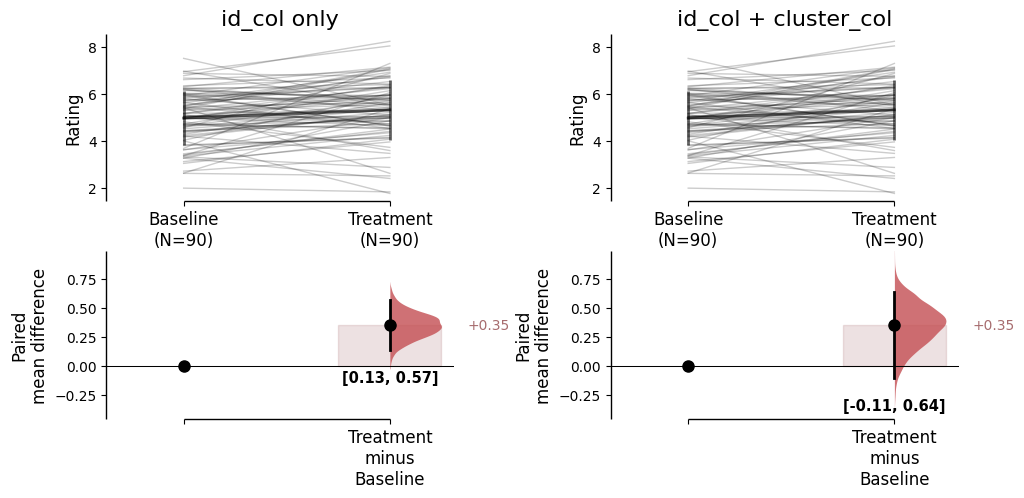

In [10]:
bounds = pd.concat([naive.mean_diff.results[["bca_low", "bca_high"]],
                    clustered.mean_diff.results[["bca_low", "bca_high"]]])
shared_ylim = (bounds.bca_low.min() - 0.35, bounds.bca_high.max() + 0.35)
palette = {"Baseline": "#4C72B0", "Treatment": "#C44E52"}  # a non-neutral palette

f, axx = plt.subplots(ncols=2, figsize=(11, 5),
                      gridspec_kw={"wspace": 0.45})
for ax, dabest_obj, title in [(axx[0], naive, "id_col only"),
                              (axx[1], clustered, "id_col + cluster_col")]:
    dabest_obj.mean_diff.plot(ax=ax, delta_dot=False,
                              contrast_paired_lines=False,
                              float_contrast=False,
                              custom_palette=palette,
                              contrast_marker_size=8,
                              contrast_ylim=shared_ylim,
                              title=title)

    result = dabest_obj.mean_diff.results.iloc[0]
    tick = ax.contrast_axes.get_xticks()[-1]
    ax.contrast_axes.text(tick, result.bca_low - 0.3,
                          "[{:.2f}, {:.2f}]".format(result.bca_low, result.bca_high),
                          ha="center", va="bottom", fontsize=10.5, fontweight="bold")

Inspect the two bracketed intervals: the cluster-naive one sits entirely above 0, while the
cluster-aware one spans across the zero line. This could impact on the conclusions drawn from the estimation plot.
Same data, same point estimate, opposite verdict at the conventional 5% threshold. Treating each dummy ID as an independent participant could lead to reporting more certainty in an effect size than is warranted by the data, once cluster-correlation is accounted for in resampling. This is the practical implication of the pseudoreplication concern that motivates `cluster_col`.

## Does it matter for real inference? A coverage check

One worked example makes the risk concrete, but could this particular result be a fluke of this
particular random dataset? Because this dataset is simulated, we know the true effect
(`true_effect = 0.3`) exactly. That
lets us ask the question a single dataset can't answer: across many independent samples from the
same population, how often does each method's 95% interval actually contain the true effect? A
trustworthy 95% interval should hit close to 95% of the time; consistently missing more often
than that means the interval is too narrow to be trusted.

We repeat the simulation above 200 times with fresh random data each time, and compute both a
naive and a cluster-aware bootstrap interval for each dataset, calling the same lower-level
functions that `dabest.load()` uses internally, so that the whole comparison runs in a few
seconds instead of a few minutes.

In [ ]:
from dabest._stats_tools import confint_2group_diff as ci2g

def simulate_dataset(seed, n_participants=15, n_stimuli=6, true_effect=0.3,
                     participant_sd=1.4, noise_sd=0.6):
    rng = np.random.default_rng(seed)
    sensitivity = rng.normal(1, participant_sd, n_participants)
    control, test, cluster = [], [], []
    for p in range(n_participants):
        for s in range(n_stimuli):
            stim_baseline = rng.normal(5, 1.0)
            control.append(stim_baseline + rng.normal(0, noise_sd))
            test.append(stim_baseline + true_effect * sensitivity[p] + rng.normal(0, noise_sd))
            cluster.append(p)
    return np.array(control), np.array(test), np.array(cluster)

def percentile_ci(bootstraps, ci=95):
    lo, hi = np.percentile(bootstraps, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi

n_simulated_datasets = 200
resamples_per_dataset = 1000
true_effect = 0.3

naive_hits = cluster_hits = 0
naive_widths, cluster_widths = [], []

for seed in range(n_simulated_datasets):
    control, test, cluster = simulate_dataset(seed, true_effect=true_effect)

    boot_naive = ci2g.compute_bootstrapped_diff(
        control, test, "baseline", "mean_diff", resamples_per_dataset, seed)
    boot_cluster = ci2g.compute_cluster_bootstrapped_diff(
        control, test, cluster, cluster, "baseline", "mean_diff", resamples_per_dataset, seed)

    lo_n, hi_n = percentile_ci(boot_naive)
    lo_c, hi_c = percentile_ci(boot_cluster)

    naive_hits += lo_n <= true_effect <= hi_n
    cluster_hits += lo_c <= true_effect <= hi_c
    naive_widths.append(hi_n - lo_n)
    cluster_widths.append(hi_c - lo_c)

coverage = pd.DataFrame({
    "method": ["id_col only (naive)", "id_col + cluster_col"],
    "95% CI covers the true effect": [naive_hits / n_simulated_datasets, cluster_hits / n_simulated_datasets],
    "mean CI width": [np.mean(naive_widths), np.mean(cluster_widths)],
}).set_index("method").round(3)
coverage

,95% CI covers the true effect,mean CI width
method,,
id_col only (naive),0.815,0.382
id_col + cluster_col,0.900,0.511


With a nominal target of 95%, the naive dummy-ID bootstrap covers the true effect noticeably
less often than that across these 200 simulated datasets, because it cannot tell that groups of sets came from the same participant and so understates the true sampling uncertainty. Once `cluster_col` tells it, coverage recovers to close to the nominal 95%, at the cost of a correspondingly wider (but now trustworthy) interval.

Similarly, the permutation test also yields p-values biased to be too small in the cluster-naive case; defining the `cluster_col` argument ensures permuation test is reshuffled at the cluster level, producing values that account for the cluster-correlation.

## Summary

- Use `cluster_col` whenever a real participant (or other independent unit) contributes more
  than one row of `id_col`, whether the design is paired or unpaired.
- Ignoring clustering can lead to confidence intervals being estimated as too narrow.
- The point estimate (the mean difference itself) is unaffected; only the bootstrap confidence intervals change, because they are the parts of the analysis that depend on which observations are treated as independent.
- The interval widens to reflect real between-participant variability that a cluster-naive bootstrap cannot account for. The example simulation above shows the naive interval can give a false sense of precision.
- Permutation tests are similarly reshuffled at the cluster-level, yielding larger values than the cluster-naive approach.
- The parametric and rank-based tests reported in `.statistical_tests` (Welch's t, Mann-Whitney, Wilcoxon, and so on) do not account for clustering and are unaffected by `cluster_col`; prefer the cluster-aware bootstrap interval for clustered data.